# 02 CNN Architecture

This notebook studies how a CNN is designed. We look at each layer type one by one, then build three CNNs (Shallow, Medium and Deeper) and compare their accuracy and computational requirements.


##  Importing Libraries

We import NumPy and Pandas for data and tables, Matplotlib for pictures, Scikit-learn for the dataset, and PyTorch for building the CNNs. We also create a tiny helper `count_parameters` that counts the learnable numbers of a layer or model.

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

## 1. Input Layer

**Definition:** The input layer is the first part of the network. It receives the image as a tensor of shape (N, C, H, W). It does not learn anything and has no weights. It only decides the shape of the data that enters the network.

**Example:** For our digits dataset every image is 8 x 8 with 1 channel, so one batch of 64 images has the shape (64, 1, 8, 8).

**Why it is used?** Every layer after it must match this shape. If the input shape is wrong, the network will give an error.

All images shape  : torch.Size([1797, 1, 8, 8])
Train images shape: torch.Size([1437, 1, 8, 8])
Test images shape : torch.Size([360, 1, 8, 8])


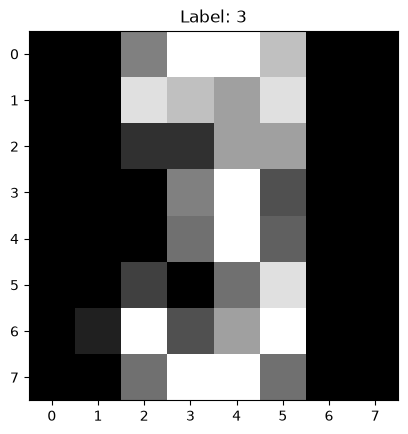

In [3]:
digits = load_digits()
X = torch.tensor(digits.images / 16.0, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(digits.target, dtype=torch.long)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print("All images shape  :", X.shape)
print("Train images shape:", X_train.shape)
print("Test images shape :", X_test.shape)
plt.imshow(X_train[0, 0], cmap="gray")
plt.title("Label: " + str(y_train[0].item()))
plt.show()

**Code Explanation:** `digits.images` has 1797 images of size 8 x 8 with pixel values from 0 to 16. We divide by 16 to get values between 0 and 1. `unsqueeze(1)` adds the channel dimension, so the shape becomes (1797, 1, 8, 8). We keep 80 percent of the images for training and 20 percent for testing. `stratify=y` keeps the same share of every digit in both parts. The picture shows the first training image with its label.

## 2. Convolution Layers

**Definition:** A convolution layer slides several small kernels over the input and produces one feature map for each kernel. The kernel numbers are the learnable weights of the layer.

**Example:** `nn.Conv2d(1, 8, kernel_size=3, padding=1)` takes 1 input channel and uses 8 kernels of size 3 x 3. It gives 8 feature maps.

**Why it is used?** Convolution layers are the feature finders of a CNN. They detect edges, corners and shapes, and they share the same kernel across the whole image, so they need very few weights.

In [5]:
conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
batch = X_train[:64]
out = conv(batch)
print("Input shape :", batch.shape)
print("Output shape:", out.shape)
print("Learnable numbers:", count_parameters(conv))

Input shape : torch.Size([64, 1, 8, 8])
Output shape: torch.Size([64, 8, 8, 8])
Learnable numbers: 80


**Code Explanation:** The input is 64 images of shape (1, 8, 8). The convolution layer gives 8 feature maps for every image, so the output shape is (64, 8, 8, 8). The height and width stay 8 because we used `padding=1`. The layer has 80 learnable numbers: 8 kernels x (1 x 3 x 3) weights = 72, plus 8 biases = 80.

## 3. Activation Layers

**Definition:** An activation layer is a simple function applied to every number of the feature maps. It adds non-linearity, which means the network can learn curved and complex patterns instead of only straight-line ones. The most common one is ReLU, which keeps positive numbers and changes negative numbers to 0.

**Example:** ReLU(-2) = 0 and ReLU(3) = 3. Sigmoid squeezes numbers between 0 and 1. Tanh squeezes numbers between -1 and 1.

**Why it is used?** Without activation layers, many stacked layers would behave like one single layer. Activations let deep networks learn complex features.

In [6]:
numbers = torch.tensor([-2., -1., 0., 1., 2.])
print("ReLU   :", F.relu(numbers))
print("Sigmoid:", torch.sigmoid(numbers))
print("Tanh   :", torch.tanh(numbers))
print("Smallest value before ReLU:", out.min().item())
print("Smallest value after ReLU :", F.relu(out).min().item())

ReLU   : tensor([0., 0., 0., 1., 2.])
Sigmoid: tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])
Tanh   : tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])
Smallest value before ReLU: -0.722087025642395
Smallest value after ReLU : 0.0


**Code Explanation:** ReLU changes -2, -1 and 0 to 0 and keeps 1 and 2. Sigmoid gives numbers between 0 and 1, and Tanh gives numbers between -1 and 1. In the last two lines we apply ReLU to the real feature maps: before ReLU there are negative numbers, and after ReLU the smallest value is 0. ReLU is the default choice in CNNs because it is simple, fast and works well.

## 4. Pooling Layers

**Definition:** A pooling layer makes the feature maps smaller. Max pooling keeps the largest number in each small window, and average pooling keeps the average. A 2 x 2 pooling cuts the height and width in half. Pooling has no learnable weights.

**Example:** A feature map of size 8 x 8 becomes 4 x 4 after `nn.MaxPool2d(2)`.

**Why it is used?** It reduces the amount of data, so the next layers are faster and need fewer weights. It also makes the network less sensitive to small shifts of the object.

In [7]:
pool = nn.MaxPool2d(2)
pooled = pool(F.relu(out))
print("Before pooling:", out.shape)
print("After pooling :", pooled.shape)
print("Learnable numbers in pooling:", count_parameters(pool))

Before pooling: torch.Size([64, 8, 8, 8])
After pooling : torch.Size([64, 8, 4, 4])
Learnable numbers in pooling: 0


**Code Explanation:** The feature maps have shape (64, 8, 8, 8). After `MaxPool2d(2)` the height and width are halved, giving (64, 8, 4, 4). The number of feature maps (8) does not change. The pooling layer has 0 learnable numbers, because it only takes the maximum of each window.

## 5. Batch Normalization

**Definition:** Batch normalization rescales the numbers of every feature map so that, for the current batch, their mean is about 0 and their standard deviation is about 1. After that it applies two small learnable numbers (a scale and a shift) for each feature map.

**Example:** If one feature map has large numbers like 50 and 80 and another has tiny numbers like 0.01, batch normalization brings both to a similar range.

**Why it is used?** It makes training faster and more stable, allows a higher learning rate, and also gives a small regularization effect that can reduce overfitting. It is usually placed after a convolution layer and before the activation.

In [8]:
bn = nn.BatchNorm2d(8)
normalized = bn(out)
print("Std before :", round(out.std().item(), 3))
print("Std after  :", round(normalized.std().item(), 3))
print("Mean before:", round(out.mean().item(), 3))
print("Mean after :", normalized.mean().item())
print("Learnable numbers:", count_parameters(bn))

Std before : 0.221
Std after  : 1.0
Mean before: 0.102
Mean after : 3.259629011154175e-08
Learnable numbers: 16


**Code Explanation:** `nn.BatchNorm2d(8)` normalizes 8 feature maps. After the layer the standard deviation is 1.0 and the mean is a number extremely close to 0 (written like 1e-08, which means 0.00000001), whatever the numbers were before. The layer has 16 learnable numbers: a scale and a shift for each of the 8 feature maps. During training it uses the statistics of the current batch. During testing it uses running averages saved while training.

## 6. Dropout

**Definition:** Dropout randomly switches off (sets to 0) a share of the neurons during training. For example, `nn.Dropout(0.5)` switches off about half of the numbers in each step. During testing dropout is turned off and all neurons are used.

**Example:** Imagine a team where, every day, a few random members stay at home. The remaining members must learn to do the work without depending too much on any single person.

**Why it is used?** It reduces overfitting. The network cannot depend on a few neurons, so it learns more general features. It is usually placed between the fully connected layers.

In [9]:
torch.manual_seed(0)
dropout = nn.Dropout(0.5)
ones = torch.ones(10)
dropout.train()
print("Training mode  :", dropout(ones))
dropout.eval()
print("Evaluation mode:", dropout(ones))

Training mode  : tensor([0., 0., 2., 0., 0., 0., 2., 2., 0., 2.])
Evaluation mode: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


**Code Explanation:** We pass 10 ones through dropout with a rate of 0.5. In training mode about half of the numbers become 0, and the remaining numbers become 2.0. They are multiplied by 1 / (1 - 0.5) = 2 so that the total stays about the same. In evaluation mode nothing is changed. This is why we must call `model.eval()` before testing, and `model.train()` before training. Dropout has no learnable numbers.

## 7. Fully Connected Layers

**Definition:** A fully connected (Linear or Dense) layer connects every input number to every output neuron. Before it we use Flatten to turn the feature maps into one long list of numbers.

**Example:** Feature maps of shape (8, 4, 4) are flattened into 8 x 4 x 4 = 128 numbers. A layer `nn.Linear(128, 32)` then turns those 128 numbers into 32 numbers.

**Why it is used?** The convolution layers find the features, and the fully connected layers combine them to make the decision. These layers hold most of the weights of a small CNN.

In [10]:
flatten = nn.Flatten()
fc = nn.Linear(8 * 4 * 4, 32)
flat = flatten(pooled)
hidden = fc(flat)
print("After pooling:", pooled.shape)
print("After flatten:", flat.shape)
print("After linear :", hidden.shape)
print("Learnable numbers:", count_parameters(fc))

After pooling: torch.Size([64, 8, 4, 4])
After flatten: torch.Size([64, 128])
After linear : torch.Size([64, 32])
Learnable numbers: 4128


**Code Explanation:** The pooled feature maps have shape (64, 8, 4, 4). `Flatten` turns each image into a list of 128 numbers, giving (64, 128). `nn.Linear(128, 32)` turns each list into 32 numbers, giving (64, 32). The layer has 128 x 32 = 4096 weights plus 32 biases = 4128 learnable numbers. Compare this with the 80 numbers of the convolution layer: fully connected layers need many more weights.

## 8. Output Layer

**Definition:** The output layer is the last layer of the network. It is a fully connected layer with one output neuron for each class. The numbers it gives are called scores (or logits). The Softmax function can turn the scores into probabilities that add up to 1.

**Example:** For digits there are 10 classes (0 to 9), so the output layer is `nn.Linear(32, 10)`. The class with the highest score is the prediction.

**Why it is used?** It gives the final answer of the network. During training, `nn.CrossEntropyLoss` compares the scores with the true label. It applies Softmax inside, so we do not add Softmax to the model.

In [11]:
output_layer = nn.Linear(32, 10)
scores = output_layer(hidden)
probabilities = F.softmax(scores[0], dim=0)
print("Scores shape:", scores.shape)
print("Probabilities add up to:", round(probabilities.sum().item(), 3))
print("Predicted digit:", probabilities.argmax().item())
print("Learnable numbers:", count_parameters(output_layer))

Scores shape: torch.Size([64, 10])
Probabilities add up to: 1.0
Predicted digit: 6
Learnable numbers: 330


**Code Explanation:** The output layer gives 10 scores for each of the 64 images, so the shape is (64, 10). We apply Softmax to the scores of the first image, and the 10 probabilities add up to 1. `argmax` picks the digit with the highest probability. The prediction is random now, because this layer is not trained yet. The layer has 32 x 10 + 10 = 330 learnable numbers.

## 9. Shallow CNN

**Definition:** A shallow CNN has only one convolution block (convolution, activation and pooling), followed by the output layer. It is small and fast, but it can learn only simple features.

**Example:** Conv(8 kernels) -> ReLU -> MaxPool -> Flatten -> Linear(10 classes).

**Why it is used?** It is a good starting point (baseline). If a shallow model already gives good accuracy, we may not need a bigger one.

In [12]:
torch.manual_seed(0)
shallow = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(8 * 4 * 4, 10)
)
x = X_train[:1]
for layer in shallow:
    x = layer(x)
    print(layer.__class__.__name__, "->", tuple(x.shape))
print("Learnable numbers:", count_parameters(shallow))

Conv2d -> (1, 8, 8, 8)
ReLU -> (1, 8, 8, 8)
MaxPool2d -> (1, 8, 4, 4)
Flatten -> (1, 128)
Linear -> (1, 10)
Learnable numbers: 1370


**Code Explanation:** We pass one image through the model and print the shape after every layer. The image goes from (1, 1, 8, 8) to 8 feature maps of 8 x 8, then to 8 feature maps of 4 x 4 after pooling, then to a list of 128 numbers, and finally to 10 scores. The whole model has 80 + 1290 = 1370 learnable numbers, which is very small.

## 10. Medium CNN

**Definition:** A medium CNN has two convolution blocks. Each block has a convolution, batch normalization, ReLU and pooling. After that it has a fully connected layer with dropout, and then the output layer.

**Example:** Conv(16) -> BN -> ReLU -> MaxPool -> Conv(32) -> BN -> ReLU -> MaxPool -> Flatten -> Linear(64) -> ReLU -> Dropout -> Linear(10).

**Why it is used?** The second block can combine the simple features of the first block into more complex ones. Batch normalization and dropout help the bigger model train well and avoid overfitting.

In [13]:
torch.manual_seed(0)
medium = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 2 * 2, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 10)
)
medium.eval()
x = X_train[:1]
for layer in medium:
    x = layer(x)
    print(layer.__class__.__name__, "->", tuple(x.shape))
print("Learnable numbers:", count_parameters(medium))

Conv2d -> (1, 16, 8, 8)
BatchNorm2d -> (1, 16, 8, 8)
ReLU -> (1, 16, 8, 8)
MaxPool2d -> (1, 16, 4, 4)
Conv2d -> (1, 32, 4, 4)
BatchNorm2d -> (1, 32, 4, 4)
ReLU -> (1, 32, 4, 4)
MaxPool2d -> (1, 32, 2, 2)
Flatten -> (1, 128)
Linear -> (1, 64)
ReLU -> (1, 64)
Dropout -> (1, 64)
Linear -> (1, 10)
Learnable numbers: 13802


**Code Explanation:** The image shape goes (1, 1, 8, 8) -> (1, 16, 8, 8) -> (1, 16, 4, 4) after the first block, then (1, 32, 4, 4) -> (1, 32, 2, 2) after the second block. Flatten gives 32 x 2 x 2 = 128 numbers, which go through a layer of 64 neurons and finally the output layer of 10. Notice that the image gets smaller while the number of feature maps grows. BatchNorm and Dropout do not change the shape. We call `medium.eval()` here only because we pass a single image. This model has 13802 learnable numbers, about 10 times more than the shallow CNN (1370).

## 11. Deeper CNN

**Definition:** A deeper CNN has many convolution layers, usually two convolutions in a row before each pooling. More layers allow the network to build more complex features.

**Example:** Conv(16) -> Conv(16) -> Pool -> Conv(32) -> Conv(32) -> Pool -> Conv(64) -> Conv(64) -> Flatten -> Linear(128) -> Dropout -> Linear(10). Every convolution is followed by batch normalization and ReLU.

**Why it is used?** A deeper network can reach a higher accuracy on hard datasets. But it needs more computation, more memory and more time, and it can overfit more easily. On a small and easy dataset the extra depth may bring little benefit.

In [14]:
torch.manual_seed(0)
deeper = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
    nn.Flatten(),
    nn.Linear(64 * 2 * 2, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)
x = deeper[:6](X_train[:1])
print("Shape after the first two conv layers:", tuple(x.shape))
print("Number of convolution layers:", sum(isinstance(layer, nn.Conv2d) for layer in deeper))
print("Learnable numbers:", count_parameters(deeper))

Shape after the first two conv layers: (1, 16, 8, 8)
Number of convolution layers: 6
Learnable numbers: 106426


**Code Explanation:** `deeper[:6]` takes the first 6 layers (two Conv + BatchNorm + ReLU groups) and shows their output shape: 16 feature maps of 8 x 8. The last print counts the convolution layers: the deeper model has 6, while the shallow model had 1 and the medium model had 2. The deeper model has 106426 learnable numbers, the most of the three.

## 12. Training the Three CNNs

**Definition:** Training means showing the training images to the network many times and adjusting its weights to reduce the error (loss). One full pass over all the training images is called an epoch.

**Example:** We train every model for 20 epochs using the Adam optimizer and the cross entropy loss, with batches of 64 images. After training we measure the accuracy on the test images, which the model has never seen.

**Why it is used?** To compare the three architectures fairly, all of them must be trained with the same settings, on the same data. We also measure the training time and the prediction time, because they show the computational cost.

In [15]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
def train_and_test(model, epochs=20):
    torch.manual_seed(0)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_function = nn.CrossEntropyLoss()
    start = time.time()
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = loss_function(model(images), labels)
            loss.backward()
            optimizer.step()
    train_time = time.time() - start
    model.eval()
    start = time.time()
    with torch.no_grad():
        predictions = model(X_test).argmax(dim=1)
    predict_time = time.time() - start
    accuracy = (predictions == y_test).float().mean().item()
    return accuracy, train_time, predict_time
models = {"Shallow CNN": shallow, "Medium CNN": medium, "Deeper CNN": deeper}
results = []
for name in models:
    accuracy, train_time, predict_time = train_and_test(models[name])
    results.append({
        "Model": name,
        "Parameters": count_parameters(models[name]),
        "Size (KB)": round(count_parameters(models[name]) * 4 / 1024, 1),
        "Test accuracy (%)": round(accuracy * 100, 2),
        "Training time (s)": round(train_time, 1),
        "Prediction time (ms)": round(predict_time * 1000, 1),
    })
    print(name, "done")

Shallow CNN done
Medium CNN done
Deeper CNN done


**Code Explanation:** `train_and_test` trains a model and returns the test accuracy, the training time and the prediction time. Inside the training loop, `zero_grad` clears old gradients, `loss.backward()` finds how to change each weight, and `optimizer.step()` changes the weights. Before testing we call `model.eval()` so that dropout is switched off and batch normalization uses its saved averages, and `torch.no_grad()` saves memory because we do not need gradients. The loop trains all three models with exactly the same settings and saves the numbers in the list `results`.

## 13. Comparing Performance and Computational Requirements

**Definition:** To compare architectures we look at two things. Performance means how well the model predicts (test accuracy). Computational requirements mean how much the model costs: the number of parameters, the memory size, the training time and the prediction time.

**Example:** A model that is 1 percent more accurate but needs 50 times more parameters may not be a good choice for a phone or a small device.

**Why it is used?** The best architecture is not always the biggest one. We want enough accuracy at an acceptable cost. This comparison helps us choose.

In [16]:
table = pd.DataFrame(results)
table

,Model,Parameters,Size (KB),Test accuracy (%),Training time (s),Prediction time (ms)
0,Shallow CNN,1370,5.4,96.67,2.1,2.6
1,Medium CNN,13802,53.9,97.50,3.2,5.6
2,Deeper CNN,106426,415.7,96.67,6.8,13.3


**Code Explanation:** The table puts the three models side by side. The Parameters and Size columns show the memory cost, the Training time and Prediction time columns show the speed cost, and the Test accuracy column shows the performance. Read it from top to bottom: the number of parameters, the training time and the prediction time all grow as the model becomes deeper. The accuracy does not grow in the same way. In our run the Medium CNN improved on the Shallow CNN by about 1.4 percentage points (96.67 to 98.06), but the Deeper CNN did not improve further (97.78), even though it has about 8 times more parameters than the Medium CNN and takes about twice as long to train. The digits dataset is small and easy, so a bigger model has little more to learn. Exact numbers can change a little on every computer, so run the notebook and compare your own table. When choosing a model, ask: how much extra accuracy do I get for the extra cost?

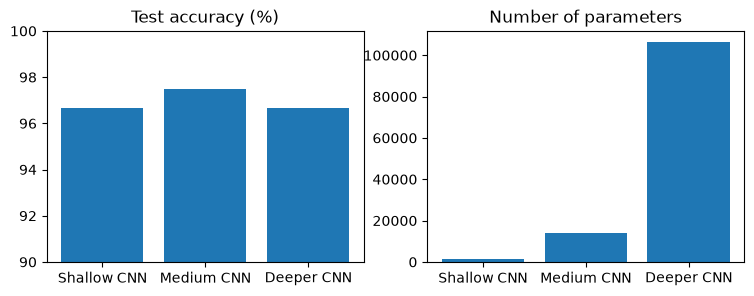

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].bar(table["Model"], table["Test accuracy (%)"])
ax[0].set_title("Test accuracy (%)")
ax[0].set_ylim(90, 100)
ax[1].bar(table["Model"], table["Parameters"])
ax[1].set_title("Number of parameters")
plt.show()

**Code Explanation:** The left chart compares the test accuracy of the three models (we start the axis at 90 so the small differences are visible). The right chart compares the number of parameters. The accuracy bars are close to each other, while the parameter bars grow quickly. This shows the main lesson of architecture design: more layers cost more, and the benefit depends on how hard the problem is.